In [1]:
# Google Play Review Exploratory Data Analysis
This notebook explores 10,000 recent Google Play reviews collected across five apps and examines rating patterns, review length, timestamps, helpful votes, app-version coverage, developer replies, and data quality.

SyntaxError: invalid syntax (2490153353.py, line 2)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/google_play_reviews.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["reply_timestamp"] = pd.to_datetime(
    df["reply_timestamp"],
    errors="coerce"
)

df["review_length"] = df["review"].str.len()

df.head()

,app_name,category,app_id,review_id,user_name,review,score,thumbs_up_count,review_created_version,timestamp,reply_content,reply_timestamp,review_length
0,Instagram,Social,com.instagram.android,c4a4658a-9b51-4ab1-ab24-c1f29223bc7a,Fathima Nizad,i love instagram because i find my panther 🤌🏻,5,0,443.0.0.48.82,2026-08-24 02:57:18,NaN,NaT,45
1,Instagram,Social,com.instagram.android,2127dd47-e505-426d-bfb0-4f9822651522,Sagar Sethi,Nice,5,0,442.0.0.46.79,2026-08-24 02:57:01,NaN,NaT,4
2,Instagram,Social,com.instagram.android,f671b0c4-ddae-4076-8af6-dbe481d2822a,Harshit Gogoi,my accounts got baned one after another.. with...,1,0,195.0.0.31.123,2026-08-24 02:56:50,NaN,NaT,64
3,Instagram,Social,com.instagram.android,fc5b0db7-203c-4155-b384-6f2c72862e72,Ifatunji Adeleke,very good to use and meet new people,5,0,NaN,2026-08-24 02:56:50,NaN,NaT,36
4,Instagram,Social,com.instagram.android,7108db14-2e55-4df0-803e-079625bc94fd,VC_ GAMER_18,Instagram is so best platform ✌️😁,5,0,443.0.0.48.82,2026-08-24 02:56:30,NaN,NaT,33


In [ ]:
## 1. Dataset Overview

In [3]:
df.shape

(10000, 13)

In [4]:
df.columns

Index(['app_name', 'category', 'app_id', 'review_id', 'user_name', 'review',
       'score', 'thumbs_up_count', 'review_created_version', 'timestamp',
       'reply_content', 'reply_timestamp', 'review_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   app_name                10000 non-null  object        
 1   category                10000 non-null  object        
 2   app_id                  10000 non-null  object        
 3   review_id               10000 non-null  object        
 4   user_name               10000 non-null  object        
 5   review                  10000 non-null  object        
 6   score                   10000 non-null  int64         
 7   thumbs_up_count         10000 non-null  int64         
 8   review_created_version  7988 non-null   object        
 9   timestamp               10000 non-null  datetime64[ns]
 10  reply_content           254 non-null    object        
 11  reply_timestamp         254 non-null    datetime64[ns]
 12  review_length           10000 non-null  int64  

In [6]:
df.isna().sum()

app_name                     0
category                     0
app_id                       0
review_id                    0
user_name                    0
review                       0
score                        0
thumbs_up_count              0
review_created_version    2012
timestamp                    0
reply_content             9746
reply_timestamp           9746
review_length                0
dtype: int64

In [7]:
df["app_name"].value_counts()

app_name
Instagram         2000
Canvas Student    2000
PayPal            2000
Strava            2000
Spotify           2000
Name: count, dtype: int64

In [ ]:
### Finding

The dataset contains 10,000 Google Play reviews across five apps, with 2,000 reviews collected for each app.

Core analytical fields such as review text, rating, timestamp, and thumbs-up count are complete. App-version information is missing for 2,012 reviews, while developer replies are available for only 254 reviews.

This indicates strong completeness for the main review fields, but more limited coverage for app-version and developer-response metadata.

In [ ]:
## 2. Rating Distribution

In [8]:
rating_counts = df["score"].value_counts().sort_index()

rating_percent = (
    df["score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Rating counts:")
print(rating_counts)

print("\nRating percentages:")
print(rating_percent)

Rating counts:
score
1    2691
2     538
3     549
4     698
5    5524
Name: count, dtype: int64

Rating percentages:
score
1    26.91
2     5.38
3     5.49
4     6.98
5    55.24
Name: proportion, dtype: float64


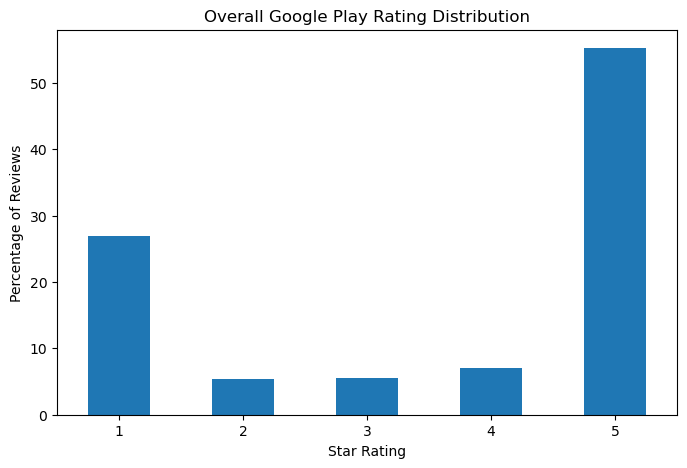

In [9]:
rating_percent.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Overall Google Play Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.show()

In [10]:
rating_by_app = (
    pd.crosstab(
        df["app_name"],
        df["score"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

rating_by_app

score,1,2,3,4,5
app_name,,,,,
Canvas Student,27.20,6.75,6.35,6.30,53.40
Instagram,17.95,3.15,3.25,6.05,69.60
PayPal,37.00,5.65,4.60,5.20,47.55
Spotify,19.20,4.35,4.75,9.25,62.45
Strava,33.20,7.00,8.50,8.10,43.20


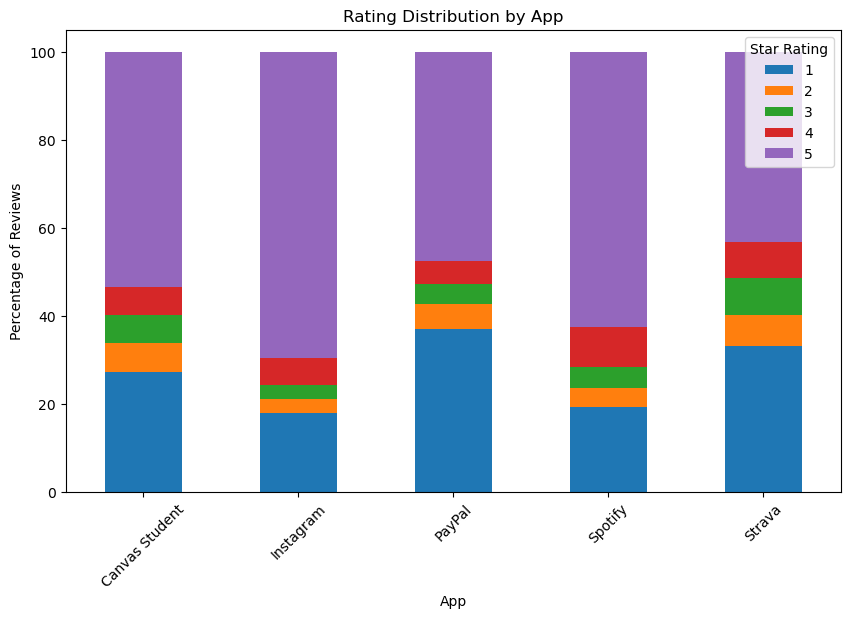

In [11]:
rating_by_app.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Rating Distribution by App")
plt.xlabel("App")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Star Rating")
plt.show()

In [ ]:
### Finding

The Google Play rating distribution is highly polarized, with five-star reviews making up the largest share of the dataset and one-star reviews representing the second-largest group, while two- to four-star ratings are much less common.

This pattern also varies substantially across apps. Instagram and Spotify have the strongest concentration of five-star reviews, whereas PayPal and Strava show much larger shares of one-star reviews. Canvas Student falls between these extremes.

Overall, the results suggest that rating behavior is both polarized and strongly app-specific.

In [12]:
## 3. Review Length Analysis

This section examines how review length varies across star ratings and across apps.

SyntaxError: invalid syntax (3471312329.py, line 3)

In [13]:
review_length_by_score = (
    df.groupby("score")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

review_length_by_score

,count,mean,median
score,,,
1,2691,145.33,99.0
2,538,156.32,124.5
3,549,142.86,92.0
4,698,81.43,45.0
5,5524,44.33,19.0


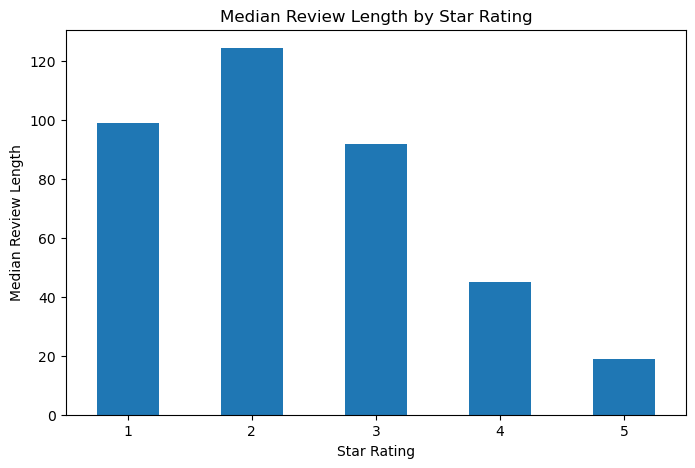

In [14]:
review_length_by_score["median"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median Review Length by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Median Review Length")
plt.xticks(rotation=0)
plt.show()

In [15]:
review_length_by_app = (
    df.groupby("app_name")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

review_length_by_app

,count,mean,median
app_name,,,
Canvas Student,2000,90.74,48.0
Instagram,2000,49.26,16.0
PayPal,2000,109.70,59.0
Spotify,2000,73.49,30.0
Strava,2000,104.47,56.0


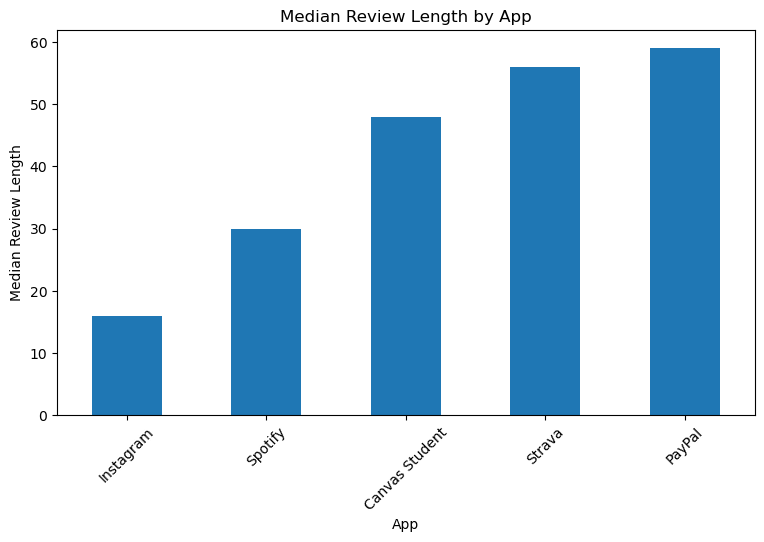

In [16]:
review_length_by_app["median"].sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Median Review Length by App")
plt.xlabel("App")
plt.ylabel("Median Review Length")
plt.xticks(rotation=45)
plt.show()

In [ ]:
### Finding

Review length varies substantially by both star rating and app.

Lower-rated reviews tend to be much longer than highly positive reviews. Two-star reviews have the highest median length, followed by one- and three-star reviews, while five-star reviews are by far the shortest. This suggests that dissatisfied or mixed-sentiment users are more likely to provide detailed explanations, whereas highly satisfied users often leave brief positive comments.

Review length also differs across apps. PayPal and Strava have the longest median reviews, while Instagram has the shortest. Canvas Student and Spotify fall in between. These differences indicate that review-writing behavior is not only related to satisfaction level but also to the type of app and user context.

In [ ]:
## 4. Helpful Votes / Thumbs Up Analysis

In [17]:
helpful_by_app = (
    df.groupby("app_name")["thumbs_up_count"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

helpful_by_app

,count,mean,median,max
app_name,,,,
Canvas Student,2000,2.04,0.0,651
Instagram,2000,0.09,0.0,9
PayPal,2000,1.04,0.0,792
Spotify,2000,0.19,0.0,66
Strava,2000,0.72,0.0,212


In [18]:
helpful_by_score = (
    df.groupby("score")["thumbs_up_count"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

helpful_by_score

,count,mean,median,max
score,,,,
1,2691,1.78,0.0,792
2,538,1.72,0.0,212
3,549,1.09,0.0,105
4,698,0.64,0.0,186
5,5524,0.25,0.0,135


In [19]:
thumbs_up_rate_by_app = (
    df.assign(
        has_thumbs_up=df["thumbs_up_count"] > 0
    )
    .groupby("app_name")["has_thumbs_up"]
    .mean()
    .mul(100)
    .round(2)
)

thumbs_up_rate_by_app

app_name
Canvas Student    39.95
Instagram          6.40
PayPal            22.60
Spotify            8.65
Strava            21.15
Name: has_thumbs_up, dtype: float64

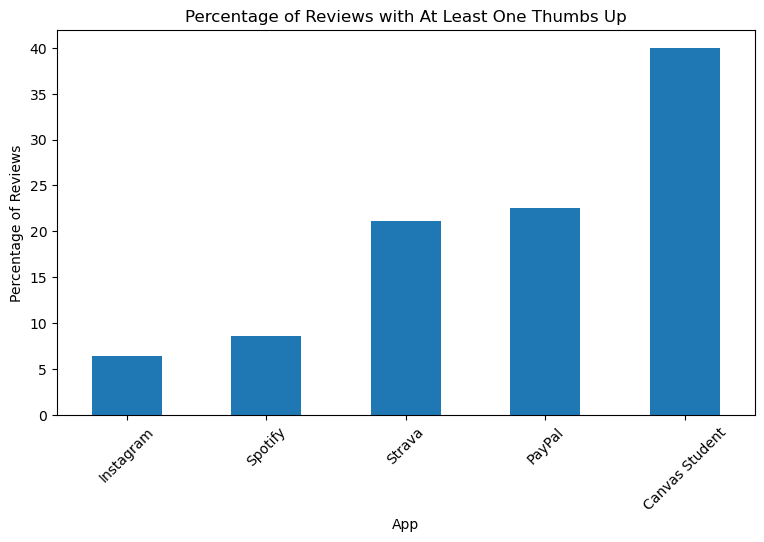

In [20]:
thumbs_up_rate_by_app.sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Percentage of Reviews with At Least One Thumbs Up")
plt.xlabel("App")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45)
plt.show()

In [21]:
correlation = df[
    ["review_length", "thumbs_up_count"]
].corr()

correlation

,review_length,thumbs_up_count
review_length,1.000000,0.139797
thumbs_up_count,0.139797,1.000000


In [ ]:
### Finding

Review engagement varies substantially across apps.

Canvas Student has the highest share of reviews receiving at least one thumbs-up vote, at about 40%, followed by PayPal and Strava at roughly 20%–23%. Instagram and Spotify have much lower engagement rates, below 10%.

Review length is only weakly associated with thumbs-up count, with a correlation of approximately 0.14. This suggests that longer reviews are slightly more likely to receive helpful votes, but review length alone does not strongly explain engagement.

Overall, helpful-vote behavior appears to be driven more by app-specific user communities and review context than by text length alone.

In [ ]:
## 5. App Version Coverage

In [22]:
version_missing_by_app = (
    df.groupby("app_name")["review_created_version"]
    .apply(lambda x: x.isna().mean() * 100)
    .round(2)
    .sort_values()
)

version_missing_by_app

app_name
Strava            11.05
Canvas Student    12.65
Spotify           16.55
PayPal            26.40
Instagram         33.95
Name: review_created_version, dtype: float64

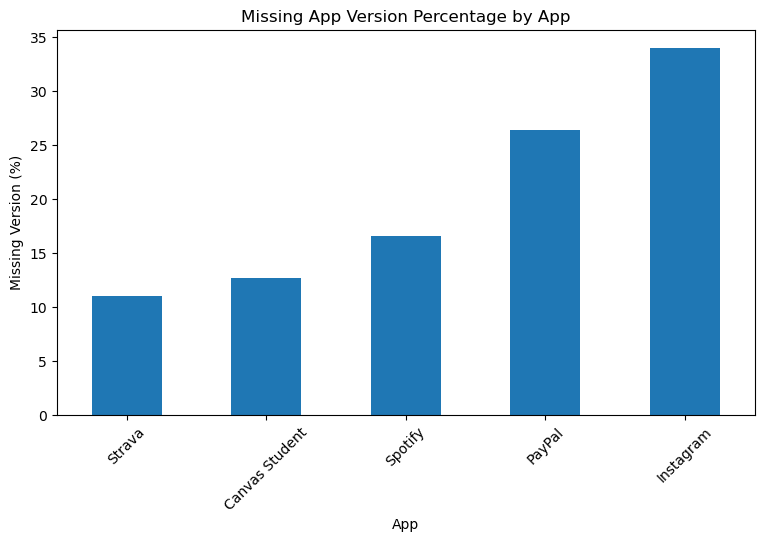

In [23]:
version_missing_by_app.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Missing App Version Percentage by App")
plt.xlabel("App")
plt.ylabel("Missing Version (%)")
plt.xticks(rotation=45)
plt.show()

In [24]:
version_coverage = (
    df["review_created_version"]
    .notna()
    .mean()
    * 100
)

print(
    "Overall app-version coverage:",
    round(version_coverage, 2),
    "%"
)

Overall app-version coverage: 79.88 %


In [25]:
top_versions_by_app = (
    df.dropna(subset=["review_created_version"])
    .groupby("app_name")["review_created_version"]
    .value_counts()
    .groupby(level=0)
    .head(5)
)

top_versions_by_app

app_name        review_created_version
Canvas Student  8.2.0                      204
                8.5.0                      172
                8.1.0                      143
                8.7.1                      132
                8.6.1                      120
Instagram       443.0.0.48.82              700
                442.0.0.46.79              158
                441.0.0.43.81               70
                440.1.0.46.86               32
                438.0.0.28.88               21
PayPal          8.107.0                   1099
                10.8.2                     152
                10.7.0                      38
                10.6.0                      26
                10.8.0                      20
Spotify         9.1.76.2055                951
                9.1.72.1891                522
                9.1.68.1888                 60
                9.1.64.1676                 29
                9.1.52.1394                 14
Strava          474.1

In [ ]:
### Finding

App-version metadata is available for most reviews overall, with approximately 79.88% coverage, but completeness varies noticeably across apps.

Strava and Canvas Student have the lowest missing-version rates, at roughly 11%–13%, while Instagram has the highest missing rate at about 34%. PayPal also shows relatively limited coverage, with more than one quarter of reviews missing version information.

The most common version values are also highly concentrated for some apps. For example, a large share of PayPal and Spotify reviews come from only one or two dominant app versions, while Canvas Student and Strava reviews are distributed across a broader set of versions.

Overall, app-version data provides a useful additional dimension for Google Play analysis, but its uneven coverage means that version-based comparisons should be interpreted cautiously.

In [ ]:
## 6. Developer Reply Analysis

In [26]:
df["has_developer_reply"] = df["reply_content"].notna()

reply_rate_by_app = (
    df.groupby("app_name")["has_developer_reply"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values()
)

reply_rate_by_app

app_name
Instagram          0.00
Strava             0.00
PayPal             0.35
Canvas Student     0.95
Spotify           11.40
Name: has_developer_reply, dtype: float64

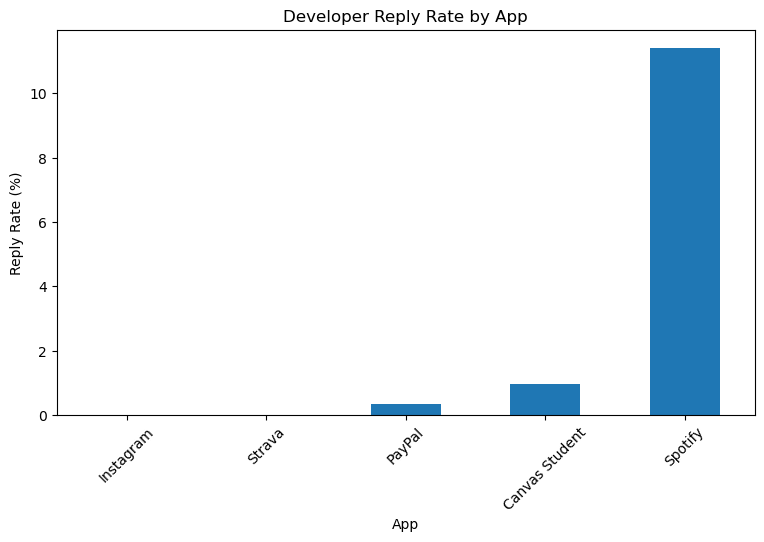

In [27]:
reply_rate_by_app.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Developer Reply Rate by App")
plt.xlabel("App")
plt.ylabel("Reply Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [28]:
reply_rate_by_score = (
    df.groupby("score")["has_developer_reply"]
    .mean()
    .mul(100)
    .round(2)
)

reply_rate_by_score

score
1    4.83
2    8.18
3    6.19
4    5.59
5    0.13
Name: has_developer_reply, dtype: float64

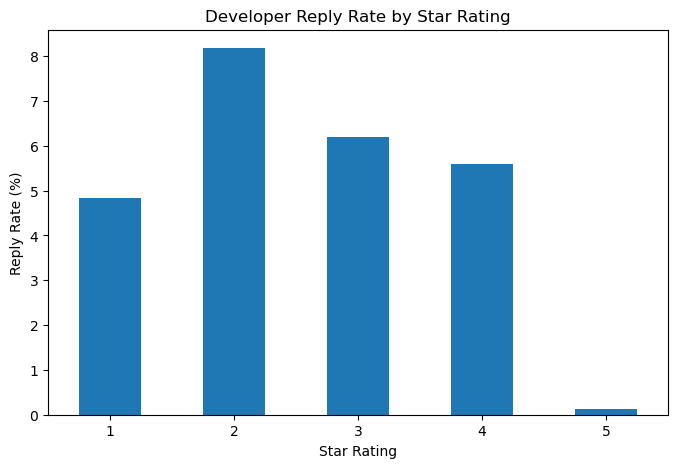

In [29]:
reply_rate_by_score.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Developer Reply Rate by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Reply Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
df["reply_delay_hours"] = (
    df["reply_timestamp"] - df["timestamp"]
).dt.total_seconds() / 3600

reply_delay_summary = (
    df.loc[df["has_developer_reply"], "reply_delay_hours"]
    .describe()
)

reply_delay_summary

count      254.000000
mean     -2087.466953
std       7067.009630
min     -43287.382778
25%          0.171528
50%          3.485278
75%          8.345417
max       2243.682500
Name: reply_delay_hours, dtype: float64

In [31]:
reply_delay_by_app = (
    df[df["has_developer_reply"]]
    .groupby("app_name")["reply_delay_hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

reply_delay_by_app

,count,mean,median
app_name,,,
Canvas Student,19,-5126.03,18.92
PayPal,7,-30202.42,-35185.11
Spotify,228,-971.08,3.71


In [32]:
reply_rate_app_score = (
    df.groupby(["app_name", "score"])["has_developer_reply"]
    .mean()
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
)

reply_rate_app_score

score,1,2,3,4,5
app_name,,,,,
Canvas Student,1.29,2.22,3.15,0.79,0.37
Instagram,0.00,0.00,0.00,0.00,0.00
PayPal,0.68,0.00,0.00,0.96,0.11
Spotify,30.73,47.13,31.58,20.00,0.16
Strava,0.00,0.00,0.00,0.00,0.00


In [ ]:
### Finding

Developer reply behavior is strongly app-specific rather than consistent across Google Play.

Only 254 of the 10,000 reviews received a developer reply, and 228 of those replies came from Spotify. Spotify shows a highly targeted response pattern where reply rates are much higher for 1–4 star reviews, particularly two-star reviews (47.13%), while only 0.16% of five-star reviews received a reply.

Canvas Student and PayPal have much lower reply rates across all star levels, while no developer replies were observed for Instagram or Strava in the collected sample.

Therefore, the higher overall reply rate among lower-rated reviews should not be interpreted as a general Google Play pattern. It is primarily driven by Spotify's developer-response strategy.

Calculated reply delays also produced implausible negative values for some reviews, so the timestamp fields were not used to make conclusions about developer response speed.

In [ ]:
## 7. Timestamp Coverage

In [38]:
timestamp_coverage = (
    df.groupby("app_name")["timestamp"]
    .agg(["min", "max"])
)

timestamp_coverage["coverage_days"] = (
    timestamp_coverage["max"]
    - timestamp_coverage["min"]
).dt.total_seconds() / 86400

timestamp_coverage["coverage_days"] = (
    timestamp_coverage["coverage_days"]
    .round(2)
)

timestamp_coverage

,min,max,coverage_days
app_name,,,
Canvas Student,2025-03-26 15:51:44,2026-08-23 19:45:24,515.16
Instagram,2026-08-23 10:16:59,2026-08-24 02:57:18,0.69
PayPal,2026-08-01 04:19:13,2026-08-24 02:34:56,22.93
Spotify,2026-08-21 08:37:54,2026-08-24 02:51:45,2.76
Strava,2026-05-21 09:08:31,2026-08-24 01:04:46,94.66


In [39]:
timestamp_coverage["reviews_per_day_approx"] = (
    2000 / timestamp_coverage["coverage_days"].replace(0, 1)
).round(2)

timestamp_coverage

,min,max,coverage_days,reviews_per_day_approx
app_name,,,,
Canvas Student,2025-03-26 15:51:44,2026-08-23 19:45:24,515.16,3.88
Instagram,2026-08-23 10:16:59,2026-08-24 02:57:18,0.69,2898.55
PayPal,2026-08-01 04:19:13,2026-08-24 02:34:56,22.93,87.22
Spotify,2026-08-21 08:37:54,2026-08-24 02:51:45,2.76,724.64
Strava,2026-05-21 09:08:31,2026-08-24 01:04:46,94.66,21.13


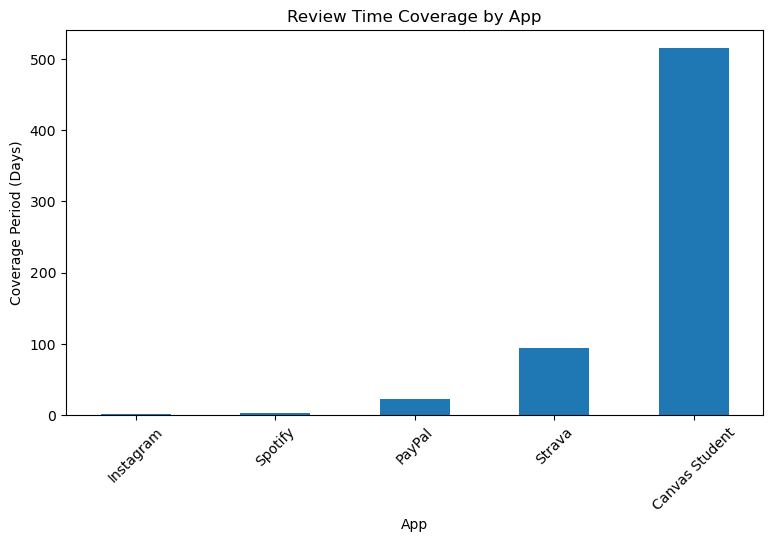

In [40]:
timestamp_coverage["coverage_days"].sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Review Time Coverage by App")
plt.xlabel("App")
plt.ylabel("Coverage Period (Days)")
plt.xticks(rotation=45)
plt.show()

In [36]:
df["review_month"] = (
    df["timestamp"]
    .dt.to_period("M")
    .astype(str)
)

reviews_by_month = (
    df.groupby(["review_month", "app_name"])
    .size()
    .unstack(fill_value=0)
)

reviews_by_month

app_name,Canvas Student,Instagram,PayPal,Spotify,Strava
review_month,,,,,
2025-03,19,0,0,0,0
2025-04,127,0,0,0,0
2025-05,110,0,0,0,0
2025-06,92,0,0,0,0
2025-07,98,0,0,0,0
2025-08,130,0,0,0,0
2025-09,208,0,0,0,0
2025-10,217,0,0,0,0
2025-11,128,0,0,0,0


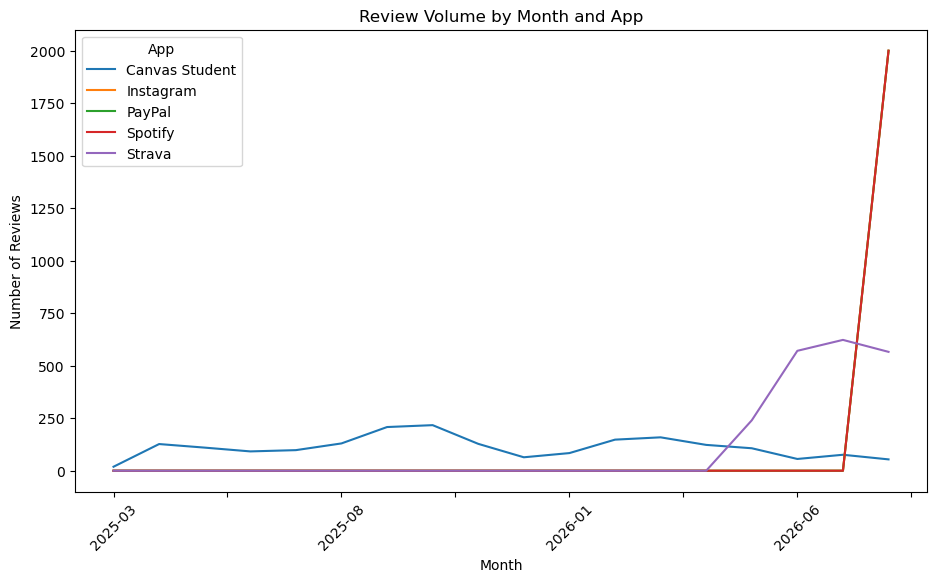

In [37]:
reviews_by_month.plot(
    figsize=(11, 6)
)

plt.title("Review Volume by Month and App")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="App")
plt.show()

In [ ]:
### Finding

The 2,000-review samples cover dramatically different time periods across apps, reflecting large differences in review activity.

Instagram's 2,000 most recent reviews were generated within less than one day, while Spotify's sample covers only a few days. PayPal spans roughly three weeks, Strava about three months, and Canvas Student extends across more than a year.

This means that collecting the same number of recent reviews does not produce comparable temporal coverage across apps. High-volume apps provide a very narrow snapshot of current user feedback, whereas lower-volume apps provide a much longer historical window.

Therefore, the dataset should be interpreted as an equal-size recent-review sample across apps rather than as a uniform time-based sample. Cross-app comparisons involving trends or time should be made cautiously.

In [ ]:
## 8. Low-Information and Duplicate Reviews

In [41]:
missing_review_count = df["review"].isna().sum()

short_review_count = (
    df["review"]
    .fillna("")
    .str.strip()
    .str.len()
    .le(5)
    .sum()
)

duplicate_text_count = (
    df["review"]
    .dropna()
    .duplicated()
    .sum()
)

print("Missing review text:", missing_review_count)
print("Low-information reviews:", short_review_count)
print("Duplicate review texts:", duplicate_text_count)

Missing review text: 0
Low-information reviews: 960
Duplicate review texts: 1603


In [42]:
df["is_low_information"] = (
    df["review"]
    .fillna("")
    .str.strip()
    .str.len()
    .le(5)
)

low_info_by_app = (
    df.groupby("app_name")["is_low_information"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values()
)

low_info_by_app

app_name
Canvas Student     5.85
Strava             6.40
PayPal             6.90
Spotify           10.65
Instagram         18.20
Name: is_low_information, dtype: float64

In [43]:
low_info_by_score = (
    df.groupby("score")["is_low_information"]
    .mean()
    .mul(100)
    .round(2)
)

low_info_by_score

score
1     1.93
2     2.23
3     5.46
4    11.03
5    14.28
Name: is_low_information, dtype: float64

In [44]:
repeated_reviews = (
    df["review"]
    .dropna()
    .value_counts()
)

repeated_reviews = repeated_reviews[
    repeated_reviews > 1
]

repeated_reviews.head(20)

review
good         281
nice         110
very good     64
great         53
best          51
nice app      48
Good          48
excellent     47
good app      39
ok            30
awesome       30
love it       30
best app      29
great app     27
super         27
very nice     26
good 👍        24
amazing       22
👍             22
I love it     18
Name: count, dtype: int64

In [ ]:
### Finding

Text quality varies noticeably across apps and rating levels.

There are no missing review texts in the dataset, but 960 reviews are low-information reviews with five or fewer characters, and 1,603 review rows contain text that duplicates an earlier review. Common repeated texts include short positive expressions such as "good," "nice," "very good," "great," and "best."

Low-information reviews are much more common for highly positive ratings. Only 1.93% of one-star reviews are low-information, compared with 14.28% of five-star reviews. This is consistent with the earlier review-length analysis: dissatisfied users tend to provide more detailed feedback, while highly satisfied users are more likely to leave brief comments.

The pattern also differs across apps. Instagram has the highest low-information rate at 18.20%, while Canvas Student has the lowest at 5.85%. This suggests that text richness is influenced by both user sentiment and app-specific review behavior.

Overall, the dataset has strong field completeness, but a meaningful share of reviews provide limited unique textual information, which should be considered in downstream text analysis.

In [ ]:
## 9. Key Findings
1. **Google Play ratings are strongly polarized.**  
   Five-star reviews account for the largest share of the dataset, while one-star reviews form the second-largest group. Intermediate ratings are much less common.

2. **Rating patterns differ substantially across apps.**  
   Instagram and Spotify have much stronger concentrations of five-star reviews, while PayPal and Strava show noticeably larger shares of one-star reviews.

3. **Lower-rated reviews tend to contain more detailed feedback.**  
   One- to three-star reviews are substantially longer than five-star reviews. Five-star reviews have the shortest median length, suggesting that highly satisfied users often leave brief positive comments.

4. **Review-writing behavior is also app-specific.**  
   PayPal and Strava have the longest median review lengths, while Instagram has the shortest.

5. **Helpful-vote engagement varies widely across apps.**  
   Canvas Student has the highest share of reviews receiving at least one thumbs-up vote, while Instagram and Spotify have much lower engagement rates. Review length has only a weak positive relationship with thumbs-up count.

6. **App-version metadata provides additional analytical value but is incomplete.**  
   Approximately 80% of reviews contain app-version information, although coverage varies substantially across apps.

7. **Developer-response behavior is highly app-specific.**  
   Only 254 reviews received developer replies, and 228 of those came from Spotify. Spotify appears to target lower-rated reviews much more heavily than five-star reviews.

8. **Equal-size samples do not imply equal time coverage.**  
   The 2,000 most recent reviews for Instagram were generated within less than one day, while the Canvas Student sample spans more than a year.

9. **Field completeness is strong, but text quality is uneven.**  
   There are no missing review texts, but 960 reviews are low-information and 1,603 review rows contain text duplicating an earlier review. Low-information content is particularly common among five-star reviews.

In [ ]:
## 10. Limitations

Several limitations should be considered when interpreting the analysis.

- The dataset contains 2,000 recent reviews from each of five selected apps rather than a random sample of all Google Play reviews.
- The apps were deliberately selected from different categories to increase diversity, but five apps cannot represent the full Google Play ecosystem.
- Reviews were collected using the newest-review ordering, so temporal coverage differs substantially across apps. High-volume apps represent a very narrow time window, while lower-volume apps cover much longer periods.
- Collection was restricted to U.S. English-language Google Play results, so the findings do not represent global or multilingual review behavior.
- App-version metadata is incomplete, with 2,012 reviews missing `review_created_version`.
- Developer replies are sparse and highly concentrated in Spotify, so overall reply-rate patterns should not be generalized across Google Play.
- Review and developer-reply timestamps produced implausible negative response delays for some records. These fields were therefore not used to estimate developer response speed.
- A meaningful share of review text is extremely short or repeated, which may reduce the value of some observations for downstream text analysis.
- The analysis is exploratory and descriptive. Observed relationships should not be interpreted as causal.

In [ ]:
## 11. Steam vs. Google Play

The Google Play dataset provides several analytical dimensions that were not available, or were less prominent, in the Steam review data.

Both sources support analysis of review text, user sentiment, timestamps, engagement, and data quality. However, Google Play provides a broader range of product categories and includes additional metadata such as 1–5 star ratings, app versions, developer replies, and reply timestamps.

The broader category coverage also produces stronger cross-product variation in rating behavior, review length, engagement, and developer-response strategies. At the same time, Google Play introduces additional limitations, including uneven version coverage, sparse developer replies, and substantial differences in temporal coverage across apps.

Overall, the initial analysis suggests that Google Play offers richer dimensions for cross-category user-feedback analysis, while Steam provides more specialized behavioral metadata such as user playtime. A fuller comparison should therefore consider not only data accessibility and quality, but also the distinct analytical questions each source can support.